Example from [Matplotlib gallery](https://matplotlib.org/stable/gallery/images_contours_and_fields/image_annotated_heatmap.html)

In this example, we will be writing code to generate the following figure:

![annotated-heatmap](https://matplotlib.org/stable/_images/sphx_glr_image_annotated_heatmap_002.png)

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt

import numpy as np

In [2]:
vegetables = ['cucumber', 'tomato', 'lettuce', 'asparagus',
                'potato', 'wheat', 'barley']
row_indices = range(len(vegetables))

farmers = ['Farmer Joe', 'Upland Bros.', 'Smith Gardening',
                'Agrifun', 'Organiculture', 'BioGoods Ltd.', 'Cornylee Corp.']
col_indices = range(len(farmers))

harvest = np.array([[0.8, 2.4, 2.5, 3.9, 0.0, 4.0, 0.0],
                    [2.4, 0.0, 4.0, 1.0, 2.7, 0.0, 0.0],
                    [1.1, 2.4, 0.8, 4.3, 1.9, 4.4, 0.0],
                    [0.6, 0.0, 0.3, 0.0, 3.1, 0.0, 0.0],
                    [0.7, 1.7, 0.6, 2.6, 2.2, 6.2, 0.0],
                    [1.3, 1.2, 0.0, 0.0, 0.0, 3.2, 5.1],
                    [0.1, 2.0, 0.0, 1.4, 0.0, 1.9, 6.3]])

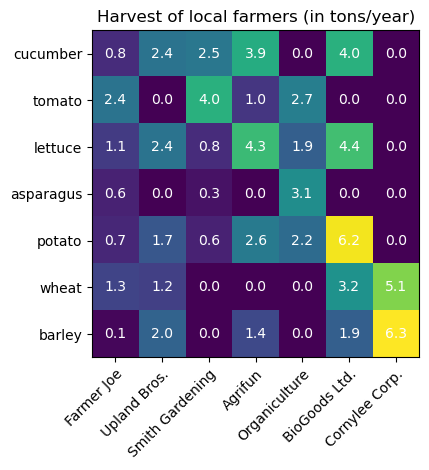

In [3]:
fig, ax = plt.subplots()
im = ax.imshow(harvest)

ax.set_xticks(col_indices, labels=farmers,
              rotation=45, ha='right', rotation_mode='anchor')

ax.set_yticks(row_indices, labels=vegetables)

for i in row_indices:
    for j in col_indices:
        text = ax.text(j, i, harvest[i, j],
                       ha='center', va='center', color='w')
        
ax.set_title('Harvest of local farmers (in tons/year)')
fig.tight_layout()

## Using helper functions to repurpose code faster

In [4]:
def my_heatmap(data, row_labels, col_labels, ax=None,
               cbar_kw=None, cbarlabel='', **kwargs):
    """
    Create a heatmap from a numpy array and two lists of labels.

    Parameters
    ----------
    data
        A 2D numpy array of shape (M, N).
    row_labels
        A list or array of length M with the labels for the rows.
    col_labels
        A list or array of length N with the labels for the columns.
    ax
        A `matplotlib.axes.Axes` instance to which the heatmap is plotted.  If
        not provided, use current Axes or create a new one.  Optional.
    cbar_kw
        A dictionary with arguments to `matplotlib.Figure.colorbar`.  Optional.
    cbarlabel
        The label for the colorbar.  Optional.
    **kwargs
        All other arguments are forwarded to `imshow`.
    """

    if ax is None:
        ax = plt.gca()

    if cbar_kw is None:
        cbar_kw = {}

    im = ax.imshow(data, **kwargs)

    cbar = ax.figure.colorbar(im, ax=ax, **cbar_kw)
    cbar.ax.set_ylabel(cbarlabel, rotation=-90, va='bottom')

    ax.set_xticks(range(data.shape[1]), labels=col_labels,
                  rotation=-30, ha='right', rotation_mode='anchor') # Major
    ax.set_xticks(np.arange(data.shape[1]+1)-0.5, minor=True) # Minor

    ax.set_yticks(range(data.shape[0]), labels=row_labels) # Major
    ax.set_yticks(np.arange(data.shape[0]+1)-0.5, minor=True) # Minor
    
    ax.spines[:].set_visible(False)

    ax.grid(which='minor', color='w', linestyle='-', linewidth=3)
    ax.tick_params(top=True, bottom=False,
                   labeltop=True, labelbottom=False) # Major
    ax.tick_params(which='minor', bottom=False, left=False) # Minor

    return im, cbar

In [7]:
def annotate_my_heatmap(im, data=None, valfmt='{x:.2f}',
                        textcolors=('black', 'white'),
                        threshold=None, **textkw):
    """
    A function to annotate a heatmap.

    Parameters
    ----------
    im
        The AxesImage to be labeled.
    data
        Data used to annotate.  If None, the image's data is used.  Optional.
    valfmt
        The format of the annotations inside the heatmap.  This should either
        use the string format method, e.g. "$ {x:.2f}", or be a
        `matplotlib.ticker.Formatter`.  Optional.
    textcolors
        A pair of colors.  The first is used for values below a threshold,
        the second for those above.  Optional.
    threshold
        Value in data units according to which the colors from textcolors are
        applied.  If None (the default) uses the middle of the colormap as
        separation.  Optional.
    **kwargs
        All other arguments are forwarded to each call to `text` used to create
        the text labels.
    """

    if not isinstance(data, (list, np.ndarray)):
        data = im.get_array()

    if threshold is not None:
        threshold = im.norm(threshold)
    else:
        threshold = im.norm(data.max())/2.0

    kw = dict(horizontalalignment='center',
              verticalalignment='center')
    kw.update(textkw)

    if isinstance(valfmt, str):
        valfmt = mpl.ticker.StrMethodFormatter(valfmt)

    texts = []
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            kw.update(color=textcolors[int(im.norm(data[i,j]) > threshold)])
            text = im.axes.text(j, i, valfmt(data[i, j], None), **kw)
            texts.append(text)

    return texts

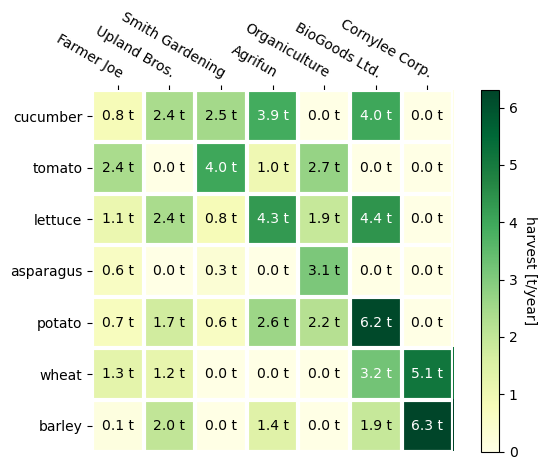

In [8]:
fig, ax = plt.subplots()

im, cbar = my_heatmap(harvest, vegetables, farmers, ax=ax,
                      cmap='YlGn', cbarlabel='harvest [t/year]')
texts = annotate_my_heatmap(im, valfmt='{x:.1f} t')

fig.tight_layout()